# Restaurant Sales Analysis — 2019–2021

**Datasets:** `resturants.csv`, `items.csv`, `sales.csv`  
**Author:** Data Science Team  
**Date:** April 2026  

---

## Objective

Analyse three years (2019–2021) of sales data across six restaurants to help management make data-driven decisions on menu optimisation, marketing investment, and expansion planning.

The analysis covers four key stages:
1. **Data Wrangling** – loading & merging tables, cleaning, missing-value treatment, normalisation, GroupBy insights  
2. **Data Analysis** – descriptive statistics, restaurant & item rankings, monthly / quarterly / yearly summaries  
3. **Data Visualisation** – dashboards for stakeholders  
4. **Report Generation** – findings and recommendations in Markdown

---
## 0. Setup – Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── visual style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('pandas :', pd.__version__)
print('numpy  :', np.__version__)
print('seaborn:', sns.__version__)

pandas : 3.0.2
numpy  : 2.4.4
seaborn: 0.13.2


---
## 1. Data Wrangling

### 1.1 Load the Raw Data

In [2]:
restaurants_raw = pd.read_csv('resturants.csv')
items_raw       = pd.read_csv('items.csv')
sales_raw       = pd.read_csv('sales.csv')

print(f'Restaurants : {restaurants_raw.shape}')
print(f'Items       : {items_raw.shape}')
print(f'Sales       : {sales_raw.shape}')

display(restaurants_raw)
display(items_raw.head())
display(sales_raw.head(10))

Restaurants : (6, 2)
Items       : (100, 5)
Sales       : (109600, 4)


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0
5,2019-01-01,19,2.89,108.0
6,2019-01-01,21,23.23,13.0
7,2019-01-01,23,10.86,10.0
8,2019-01-01,27,26.21,1.0
9,2019-01-01,35,4.36,1.0


### 1.2 Clean Column Names & Whitespace

In [3]:
def clean_df(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    for col in df.select_dtypes('object').columns:
        df[col] = df[col].str.strip()
    return df

restaurants = clean_df(restaurants_raw)
items       = clean_df(items_raw)
sales       = clean_df(sales_raw)

print('restaurants dtypes:')
print(restaurants.dtypes)
print('\nitems dtypes:')
print(items.dtypes)
print('\nsales dtypes:')
print(sales.dtypes)

restaurants dtypes:
id      int64
name      str
dtype: object

items dtypes:
id            int64
store_id      int64
name            str
kcal          int64
cost        float64
dtype: object

sales dtypes:
date              str
item_id         int64
price         float64
item_count    float64
dtype: object


### 1.3 Parse Dates & Engineer Time Features

In [4]:
sales['date']    = pd.to_datetime(sales['date'])
sales['year']    = sales['date'].dt.year
sales['month']   = sales['date'].dt.month
sales['quarter'] = sales['date'].dt.quarter
sales['week']    = sales['date'].dt.isocalendar().week.astype(int)
sales['day_name']= sales['date'].dt.day_name()

# Compute revenue per row
sales['revenue'] = sales['price'] * sales['item_count']

print(sales.dtypes)
sales.head()

date          datetime64[us]
item_id                int64
price                float64
item_count           float64
year                   int32
month                  int32
quarter                int32
week                   int64
day_name                 str
revenue              float64
dtype: object


,date,item_id,price,item_count,year,month,quarter,week,day_name,revenue
0,2019-01-01,3,29.22,2.0,2019,1,1,1,Tuesday,58.44
1,2019-01-01,4,26.42,22.0,2019,1,1,1,Tuesday,581.24
2,2019-01-01,12,4.87,7.0,2019,1,1,1,Tuesday,34.09
3,2019-01-01,13,4.18,12.0,2019,1,1,1,Tuesday,50.16
4,2019-01-01,16,3.21,136.0,2019,1,1,1,Tuesday,436.56


### 1.4 Merge Tables

In [5]:
df = (
    sales
    .merge(items.rename(columns={'id': 'item_id', 'name': 'item_name'}),
           on='item_id', how='left')
    .merge(restaurants.rename(columns={'id': 'store_id', 'name': 'restaurant'}),
           on='store_id', how='left')
)

print(f'Merged shape: {df.shape}')
df.head()

Merged shape: (109600, 15)


,date,item_id,price,item_count,year,month,quarter,week,day_name,revenue,store_id,item_name,kcal,cost,restaurant
0,2019-01-01,3,29.22,2.0,2019,1,1,1,Tuesday,58.44,1,Sweet Fruity Cake,931,29.22,Bob's Diner
1,2019-01-01,4,26.42,22.0,2019,1,1,1,Tuesday,581.24,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner
2,2019-01-01,12,4.87,7.0,2019,1,1,1,Tuesday,34.09,1,Fantastic Sweet Cola,478,4.87,Bob's Diner
3,2019-01-01,13,4.18,12.0,2019,1,1,1,Tuesday,50.16,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner
4,2019-01-01,16,3.21,136.0,2019,1,1,1,Tuesday,436.56,1,Frozen Milky Smoothy,284,3.21,Bob's Diner


### 1.5 Missing & Incorrect Value Inspection

In [6]:
print('=== isna() count per column ===')
print(df.isna().sum())

print('\n=== notna() count per column ===')
print(df.notna().sum())

=== isna() count per column ===
date          0
item_id       0
price         0
item_count    0
year          0
month         0
quarter       0
week          0
day_name      0
revenue       0
store_id      0
item_name     0
kcal          0
cost          0
restaurant    0
dtype: int64

=== notna() count per column ===
date          109600
item_id       109600
price         109600
item_count    109600
year          109600
month         109600
quarter       109600
week          109600
day_name      109600
revenue       109600
store_id      109600
item_name     109600
kcal          109600
cost          109600
restaurant    109600
dtype: int64


In [7]:
print('Negative or zero item_count:', (df['item_count'] < 0).sum())
print('Negative or zero revenue   :', (df['revenue'] < 0).sum())
print('\nUnique restaurants:', sorted(df['restaurant'].dropna().unique()))
print('Date range        :', df['date'].min().date(), '→', df['date'].max().date())
print('Years             :', sorted(df['year'].unique()))

Negative or zero item_count: 0
Negative or zero revenue   : 0



Unique restaurants: ['Beachfront Bar', "Bob's Diner", 'Corner Cafe', 'Fou Cher', 'Surfs Up', 'Sweet Shack']
Date range        : 2019-01-01 → 2021-12-31
Years             : [np.int32(2019), np.int32(2020), np.int32(2021)]


**Finding:** The dataset is complete — no missing values after the merge and no negative revenue entries. All three tables join cleanly on their foreign keys.

> **Recommendation:** Should future loads contain `NaN` values in numeric columns the recommended approach is **median imputation** (robust to outliers). For categorical columns use **mode imputation** or a dedicated `'Unknown'` category. Rows with missing key identifiers (`item_id`, `store_id`) should be dropped before merging.

### 1.6 Normalisation

**Choice: Min-Max Normalisation**  
Min-Max scaling maps each numeric column to [0, 1]. It is preferred here because:
- Revenue figures vary widely across items (e.g., drinks vs. full meals), so Z-score standardisation would not produce a meaningful centred distribution.
- Normalised values between 0 and 1 are intuitive for relative-performance dashboards.
- All values are non-negative — no sign issues.

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[['item_count_norm', 'revenue_norm']] = scaler.fit_transform(
    df[['item_count', 'revenue']]
)

print('Normalised columns (first 5 rows):')
df_norm[['date', 'restaurant', 'item_name', 'item_count', 'item_count_norm',
         'revenue', 'revenue_norm']].head()

Normalised columns (first 5 rows):


,date,restaurant,item_name,item_count,item_count_norm,revenue,revenue_norm
0,2019-01-01,Bob's Diner,Sweet Fruity Cake,2.0,0.003509,58.44,0.026268
1,2019-01-01,Bob's Diner,Amazing Steak Dinner with Rolls,22.0,0.038596,581.24,0.261255
2,2019-01-01,Bob's Diner,Fantastic Sweet Cola,7.0,0.012281,34.09,0.015323
3,2019-01-01,Bob's Diner,Sweet Frozen Soft Drink,12.0,0.021053,50.16,0.022546
4,2019-01-01,Bob's Diner,Frozen Milky Smoothy,136.0,0.238596,436.56,0.196224


> **Note:** The normalised columns (`item_count_norm`, `revenue_norm`) are kept for visualisation and model-readiness. All descriptive statistics and business reports below use the original `item_count` and `revenue` columns for interpretability.

### 1.7 GroupBy — Chunking vs. Merging

| Mode | Description | When to use |
|------|-------------|-------------|
| **Chunking** (`groupby(...).apply()`) | Split into independent sub-DataFrames, process each, then collect. | Per-group transformations (e.g., group-specific normalisation). |
| **Merging** (`groupby(...).agg()` / `.transform()`) | Aggregate or broadcast group-level summaries back to original index. | Summary tables or adding group-level columns back to every row. |

**Recommendation:** Use `groupby(...).agg()` for summary tables; use `.transform()` when adding group-level statistics back to every row for comparison.

In [9]:
# Example – restaurant-mean revenue added back to every row (transform / merging)
df['restaurant_mean_revenue'] = df.groupby('restaurant')['revenue'].transform('mean')
df[['date', 'restaurant', 'item_name', 'revenue', 'restaurant_mean_revenue']].head(8)

,date,restaurant,item_name,revenue,restaurant_mean_revenue
0,2019-01-01,Bob's Diner,Sweet Fruity Cake,58.44,240.92441
1,2019-01-01,Bob's Diner,Amazing Steak Dinner with Rolls,581.24,240.92441
2,2019-01-01,Bob's Diner,Fantastic Sweet Cola,34.09,240.92441
3,2019-01-01,Bob's Diner,Sweet Frozen Soft Drink,50.16,240.92441
4,2019-01-01,Bob's Diner,Frozen Milky Smoothy,436.56,240.92441
5,2019-01-01,Bob's Diner,Strawberry Smoothy,312.12,240.92441
6,2019-01-01,Bob's Diner,Amazing Fish with Vegetables Meal,301.99,240.92441
7,2019-01-01,Bob's Diner,Awesome Sweet Lamb Cake,108.60,240.92441


---
## 2. Data Analysis

### 2.1 Descriptive Statistics — Revenue & Item Count

In [10]:
desc_cols = ['item_count', 'revenue']

desc = df[desc_cols].agg(['mean', 'median', 'std', 'min', 'max'])
desc.loc['mode'] = [df['item_count'].mode()[0], df['revenue'].mode()[0]]
desc

,item_count,revenue
mean,6.339297,58.428271
median,0.000000,0.000000
std,30.003728,214.812200
min,0.000000,0.000000
max,570.000000,2224.800000
mode,0.000000,0.000000


In [11]:
# Full describe() for reference
df[desc_cols].describe().round(2)

,item_count,revenue
count,109600.00,109600.00
mean,6.34,58.43
std,30.00,214.81
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,570.00,2224.80


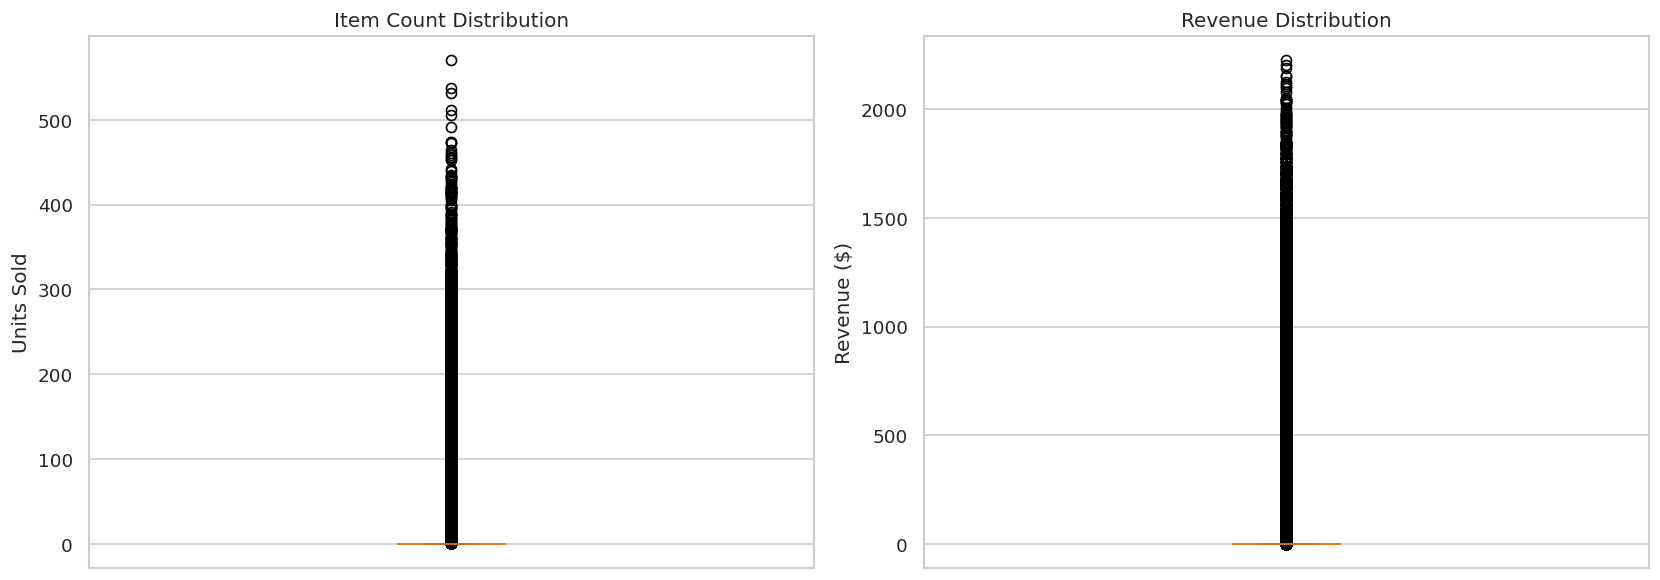

In [12]:
# Box plots for descriptive statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['item_count'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[0].set_title('Item Count Distribution')
axes[0].set_ylabel('Units Sold')
axes[0].set_xticks([])

axes[1].boxplot(df['revenue'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#DD8452', alpha=0.7))
axes[1].set_title('Revenue Distribution')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

### 2.2 Restaurant Rankings — Highest & Lowest Revenue

In [13]:
restaurant_revenue = (
    df.groupby('restaurant')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
restaurant_revenue.columns = ['Restaurant', 'Total Revenue ($)']
restaurant_revenue['Rank'] = range(1, len(restaurant_revenue) + 1)

print('=== Restaurant Revenue Ranking ===')
print(restaurant_revenue.to_string(index=False))

print(f'\nHighest revenue: {restaurant_revenue.iloc[0]["Restaurant"]} '
      f'(${restaurant_revenue.iloc[0]["Total Revenue ($)"]:.2f})')
print(f'Lowest  revenue: {restaurant_revenue.iloc[-1]["Restaurant"]} '
      f'(${restaurant_revenue.iloc[-1]["Total Revenue ($)"]:.2f})')

=== Restaurant Revenue Ranking ===
    Restaurant  Total Revenue ($)  Rank
   Bob's Diner         6337275.69     1
      Fou Cher           27885.37     2
   Corner Cafe           16551.43     3
      Surfs Up           15651.49     4
Beachfront Bar            3796.20     5
   Sweet Shack            2578.27     6

Highest revenue: Bob's Diner ($6337275.69)
Lowest  revenue: Sweet Shack ($2578.27)


In [14]:
# Top 10 items by total revenue
item_revenue = (
    df.groupby(['item_name', 'restaurant'])['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)
item_revenue.columns = ['Item', 'Restaurant', 'Total Revenue ($)']

print('=== Top 10 Items by Revenue ===')
print(item_revenue.to_string(index=False))

=== Top 10 Items by Revenue ===
                             Item  Restaurant  Total Revenue ($)
               Amazing pork lunch Bob's Diner         1094500.99
          Blue Ribbon Beef Entree Bob's Diner          999628.38
  Amazing Steak Dinner with Rolls Bob's Diner          909878.38
  Sea Bass with Vegetables Dinner Bob's Diner          685371.25
               Strawberry Smoothy Bob's Diner          683013.93
                    Mutton Dinner Bob's Diner          569937.60
             Frozen Milky Smoothy Bob's Diner          330597.90
Amazing Fish with Vegetables Meal Bob's Diner          306403.70
                     Orange Juice Bob's Diner          171547.34
                  Sweet Lamb Cake Bob's Diner          131348.00


### 2.3 Monthly Report

In [15]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = (
    df.groupby(['year', 'month'])
    .agg(total_revenue=('revenue', 'sum'),
         total_items=('item_count', 'sum'),
         transactions=('revenue', 'count'))
    .reset_index()
)
monthly['month_name'] = monthly['month'].map(month_names)
monthly['avg_order_value'] = monthly['total_revenue'] / monthly['transactions']

print(monthly.to_string(index=False))

 year  month  total_revenue  total_items  transactions month_name  avg_order_value
 2019      1      109759.77      12593.0          3100        Jan        35.406377
 2019      2      114960.23      13184.0          2800        Feb        41.057225
 2019      3      151744.62      17454.0          3100        Mar        48.949877
 2019      4      165548.24      19034.0          3000        Apr        55.182747
 2019      5      201332.60      23071.0          3100        May        64.946000
 2019      6      202030.12      23154.0          3000        Jun        67.343373
 2019      7      202401.49      23121.0          3100        Jul        65.290803
 2019      8      192296.76      22032.0          3100        Aug        62.031213
 2019      9      157886.74      17999.0          3000        Sep        52.628913
 2019     10      141260.25      16114.0          3100        Oct        45.567823
 2019     11      123750.59      14054.0          3000        Nov        41.250197
 201

### 2.4 Quarterly Report

In [16]:
quarterly = (
    df.groupby(['year', 'quarter'])
    .agg(total_revenue=('revenue', 'sum'),
         total_items=('item_count', 'sum'),
         transactions=('revenue', 'count'))
    .reset_index()
)
quarterly['avg_order_value'] = quarterly['total_revenue'] / quarterly['transactions']

print(quarterly.to_string(index=False))

 year  quarter  total_revenue  total_items  transactions  avg_order_value
 2019        1      376464.62      43231.0          9000        41.829402
 2019        2      568910.96      65259.0          9100        62.517688
 2019        3      552584.99      63152.0          9200        60.063586
 2019        4      373801.74      42595.0          9200        40.630624
 2020        1      416037.04      47278.0          9100        45.718356
 2020        2      635915.37      70654.0          9100        69.880810
 2020        3      637832.82      68241.0          9200        69.329654
 2020        4      443895.55      46408.0          9200        48.249516
 2021        1      476022.63      49494.0          9000        52.891403
 2021        2      723811.29      75287.0          9100        79.539702
 2021        3      711573.34      73894.0          9200        77.344928
 2021        4      486888.10      49294.0          9200        52.922620


### 2.5 Yearly Report

In [17]:
yearly = (
    df.groupby('year')
    .agg(total_revenue=('revenue', 'sum'),
         total_items=('item_count', 'sum'),
         transactions=('revenue', 'count'))
    .reset_index()
)
yearly['avg_order_value'] = yearly['total_revenue'] / yearly['transactions']
yearly['yoy_growth_%'] = yearly['total_revenue'].pct_change() * 100

print(yearly.to_string(index=False))

 year  total_revenue  total_items  transactions  avg_order_value  yoy_growth_%
 2019     1871762.31     214237.0         36500        51.281159           NaN
 2020     2133680.78     232581.0         36600        58.297289     13.993148
 2021     2398295.36     247969.0         36500        65.706722     12.401789


---
## 3. Data Visualisation

### 3.1 Total Revenue by Restaurant

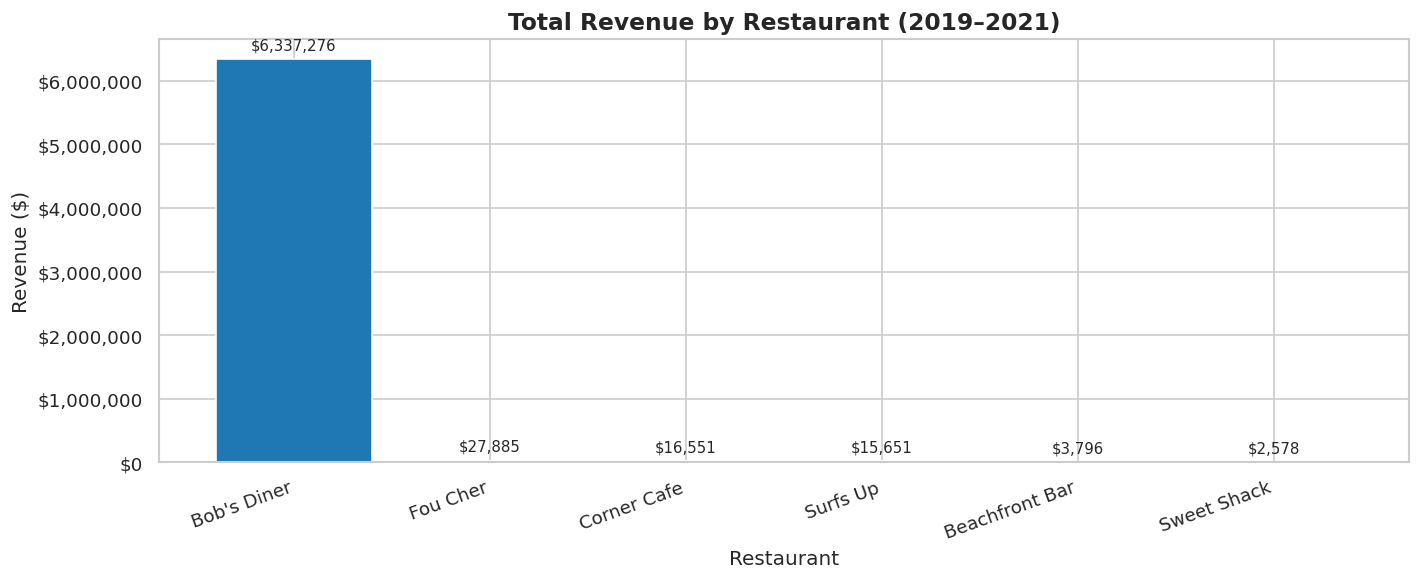

In [18]:
rest_rev = df.groupby('restaurant')['revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(rest_rev.index, rest_rev.values,
              color=sns.color_palette('tab10', len(rest_rev)))
ax.bar_label(bars, fmt='${:,.0f}', padding=4, fontsize=9)
ax.set_title('Total Revenue by Restaurant (2019–2021)', fontsize=14, fontweight='bold')
ax.set_xlabel('Restaurant')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Top 15 Items by Total Revenue

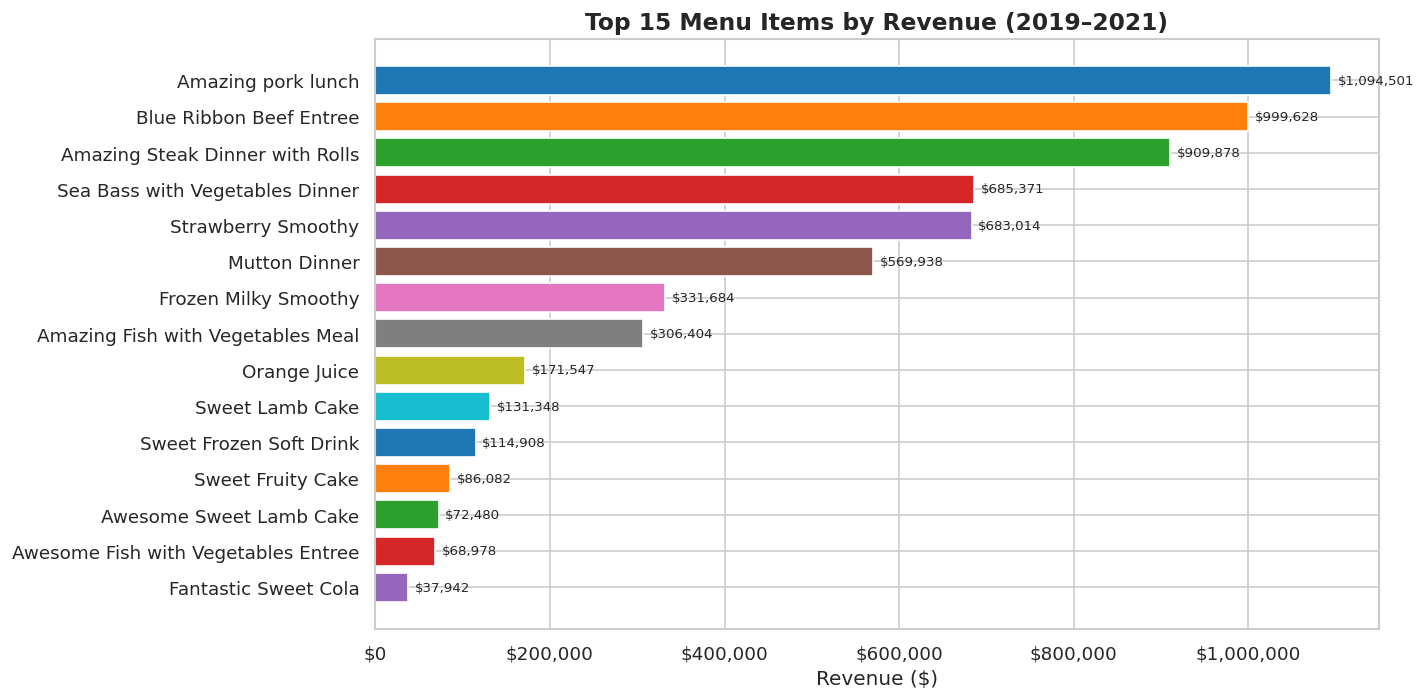

In [19]:
top_items = (
    df.groupby('item_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_items.index[::-1], top_items.values[::-1],
               color=sns.color_palette('tab10', 15)[::-1])
ax.bar_label(bars, fmt='${:,.0f}', padding=4, fontsize=8)
ax.set_title('Top 15 Menu Items by Revenue (2019–2021)', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 3.3 Annual Revenue Trend

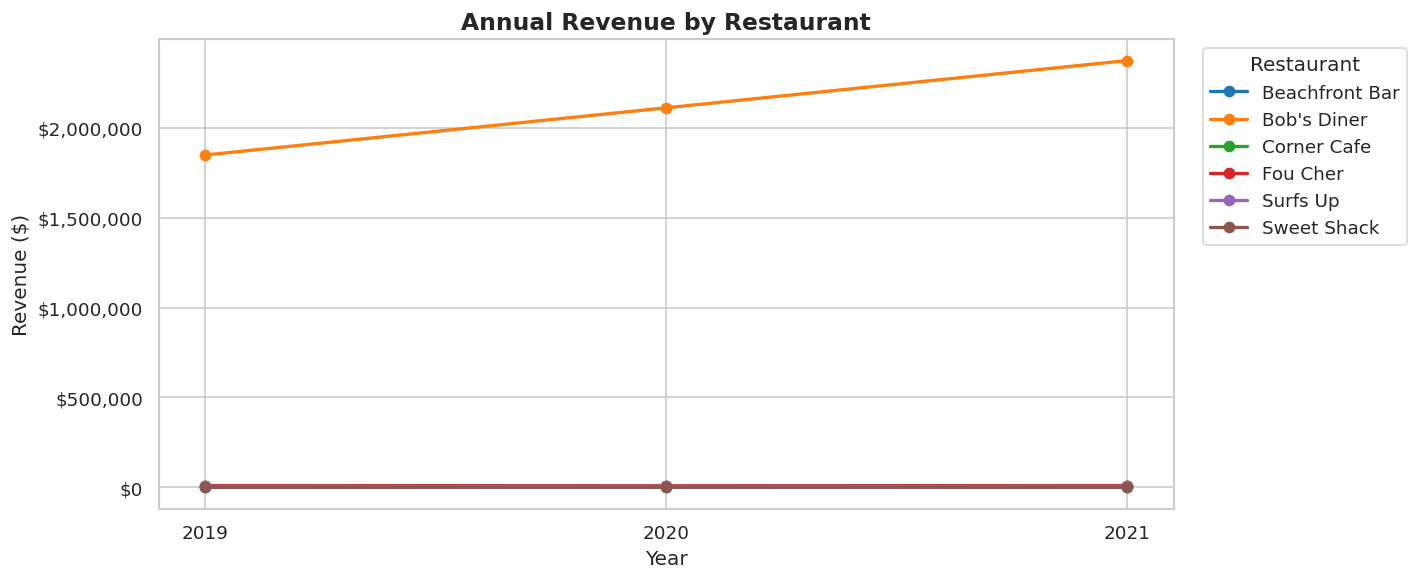

In [20]:
annual_rest = (
    df.groupby(['year', 'restaurant'])['revenue']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for rest in annual_rest['restaurant'].unique():
    sub = annual_rest[annual_rest['restaurant'] == rest]
    ax.plot(sub['year'], sub['revenue'], marker='o', linewidth=2, label=rest)

ax.set_title('Annual Revenue by Restaurant', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticks([2019, 2020, 2021])
ax.legend(title='Restaurant', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.4 Monthly Revenue Trend

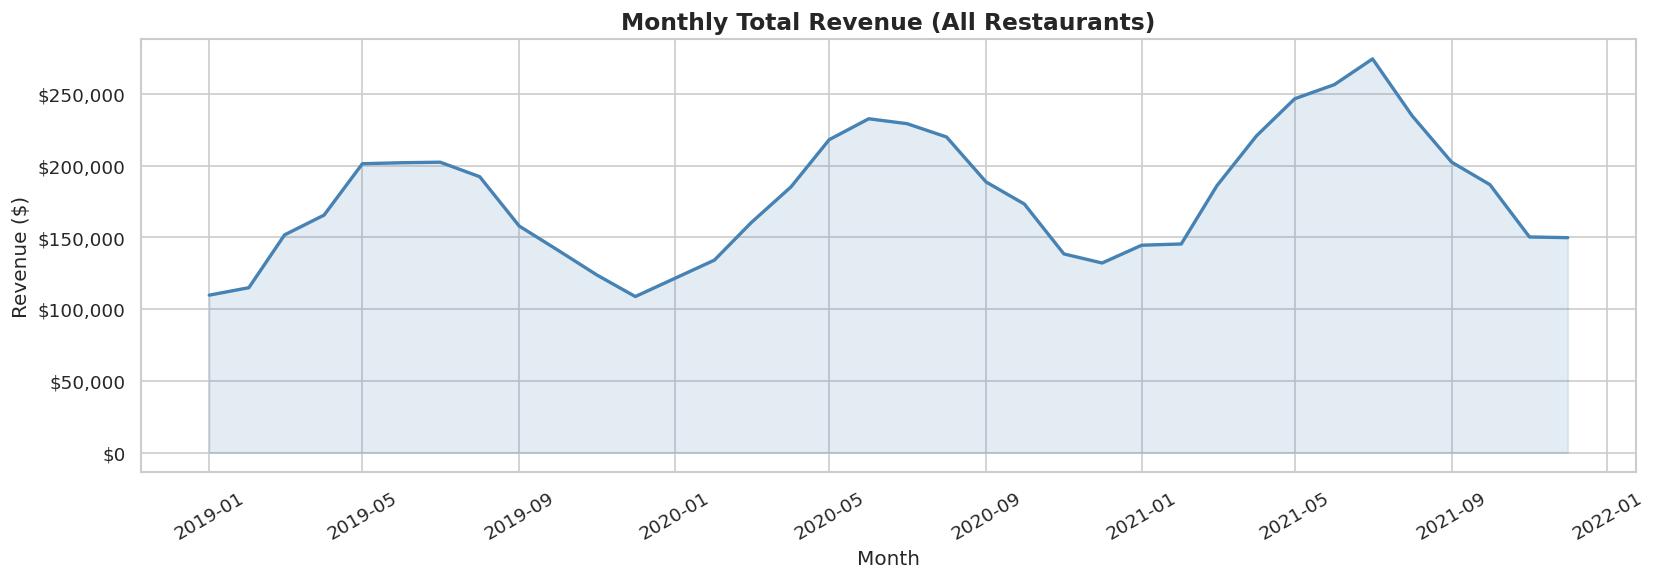

In [21]:
monthly_total = (
    df.groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
)
monthly_total['period'] = pd.to_datetime(
    monthly_total['year'].astype(str) + '-' + monthly_total['month'].astype(str) + '-01'
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_total['period'], monthly_total['revenue'],
        color='steelblue', linewidth=2)
ax.fill_between(monthly_total['period'], monthly_total['revenue'],
                alpha=0.15, color='steelblue')
ax.set_title('Monthly Total Revenue (All Restaurants)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.5 Quarterly Revenue Comparison

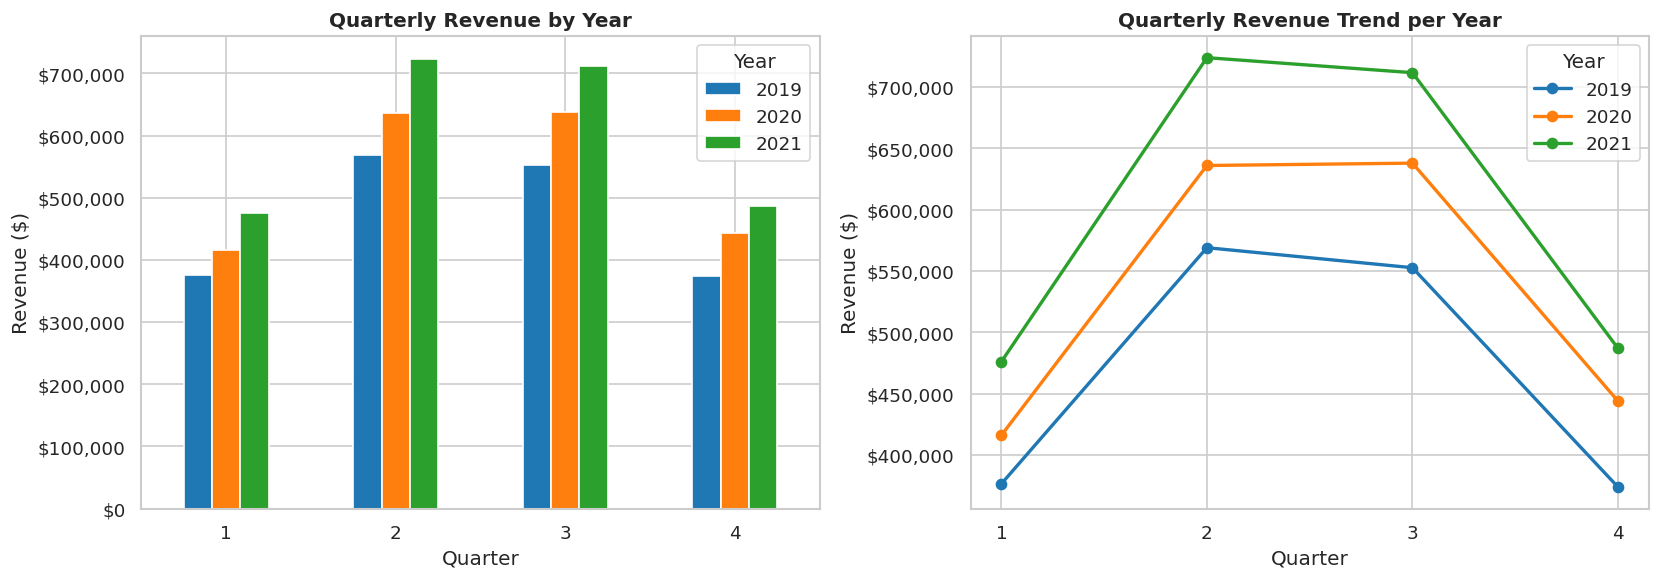

In [22]:
q_pivot = quarterly.pivot(index='quarter', columns='year', values='total_revenue')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
q_pivot.plot(kind='bar', ax=axes[0], rot=0,
             color=sns.color_palette('tab10', 3))
axes[0].set_title('Quarterly Revenue by Year', fontweight='bold')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(title='Year')

# Year-over-year growth line
for yr in [2019, 2020, 2021]:
    sub = quarterly[quarterly['year'] == yr]
    axes[1].plot(sub['quarter'], sub['total_revenue'],
                 marker='o', linewidth=2, label=str(yr))
axes[1].set_title('Quarterly Revenue Trend per Year', fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(title='Year')

plt.tight_layout()
plt.show()

### 3.6 Revenue Heatmap — Restaurant × Year

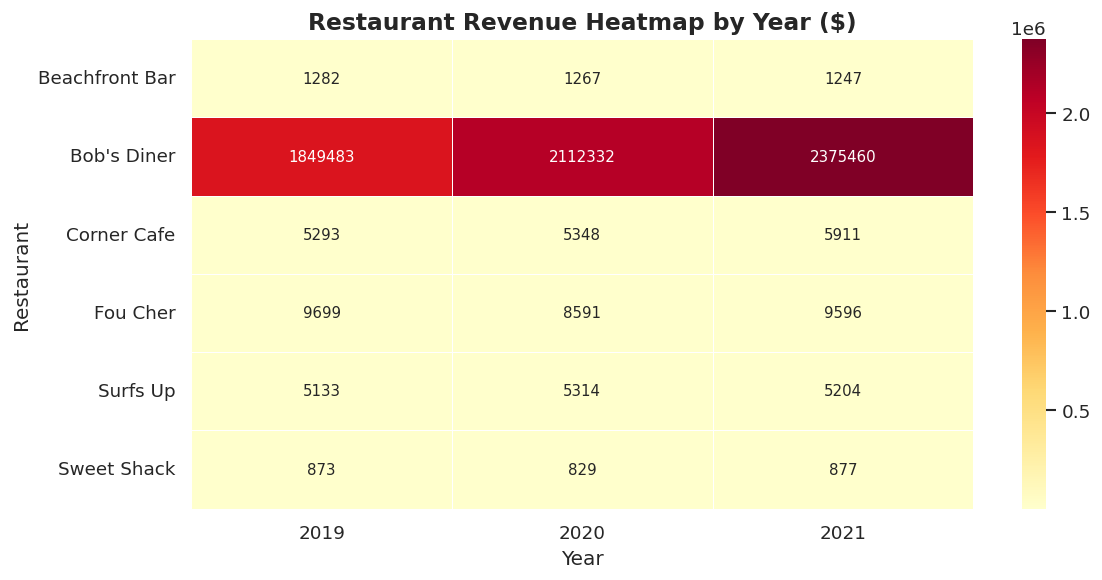

In [23]:
pivot_rest = df.pivot_table(
    values='revenue', index='restaurant', columns='year', aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_rest, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Restaurant Revenue Heatmap by Year ($)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Restaurant')
plt.tight_layout()
plt.show()

### 3.7 Revenue Heatmap — Restaurant × Month

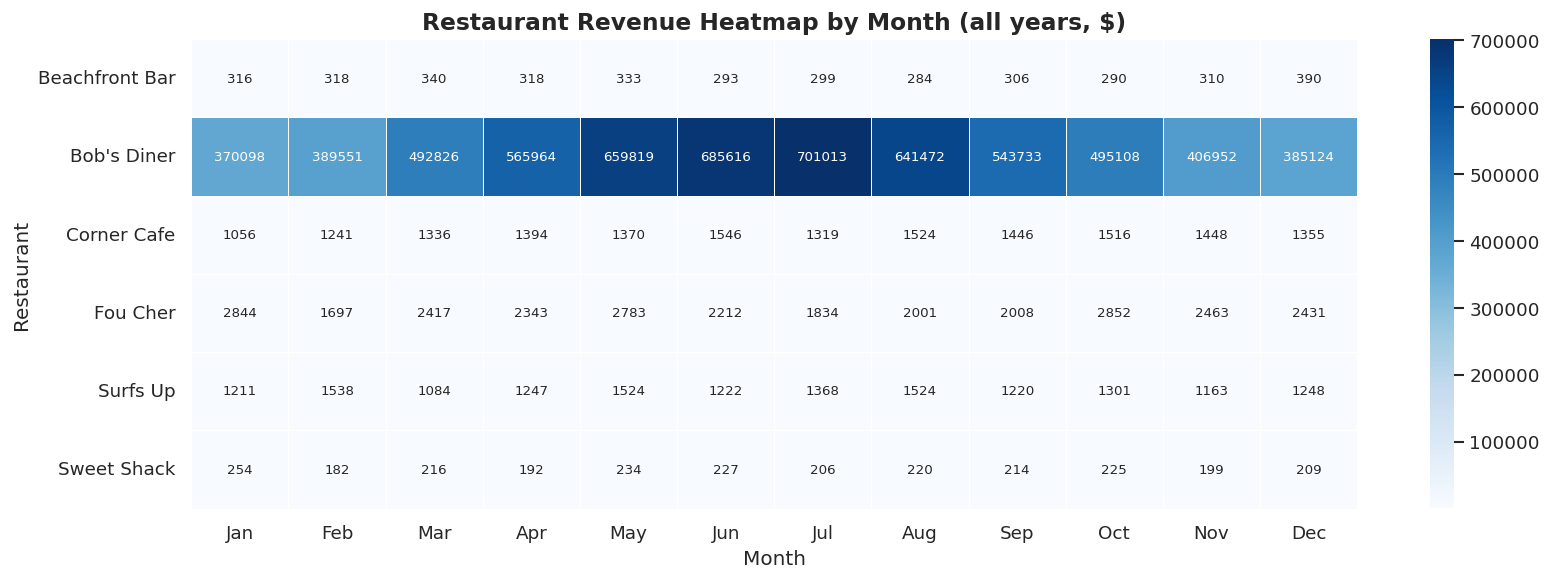

In [24]:
month_short = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

pivot_month = df.pivot_table(
    values='revenue', index='restaurant', columns='month', aggfunc='sum'
)
pivot_month.columns = [month_short[m] for m in pivot_month.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_month, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Restaurant Revenue Heatmap by Month (all years, $)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Restaurant')
plt.tight_layout()
plt.show()

### 3.8 Distribution of Revenue & Item Count

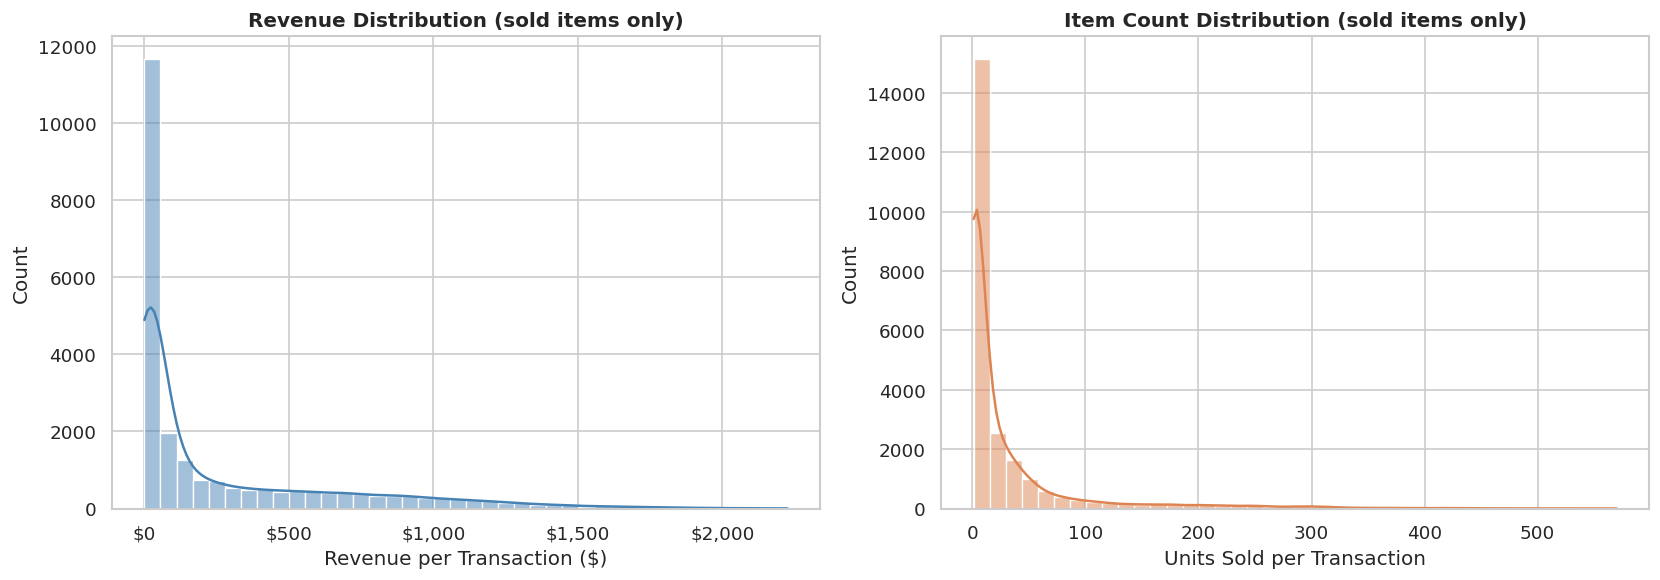

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Only rows with actual sales
sold = df[df['item_count'] > 0]

sns.histplot(sold['revenue'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Revenue Distribution (sold items only)', fontweight='bold')
axes[0].set_xlabel('Revenue per Transaction ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.histplot(sold['item_count'], bins=40, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Item Count Distribution (sold items only)', fontweight='bold')
axes[1].set_xlabel('Units Sold per Transaction')

plt.tight_layout()
plt.show()

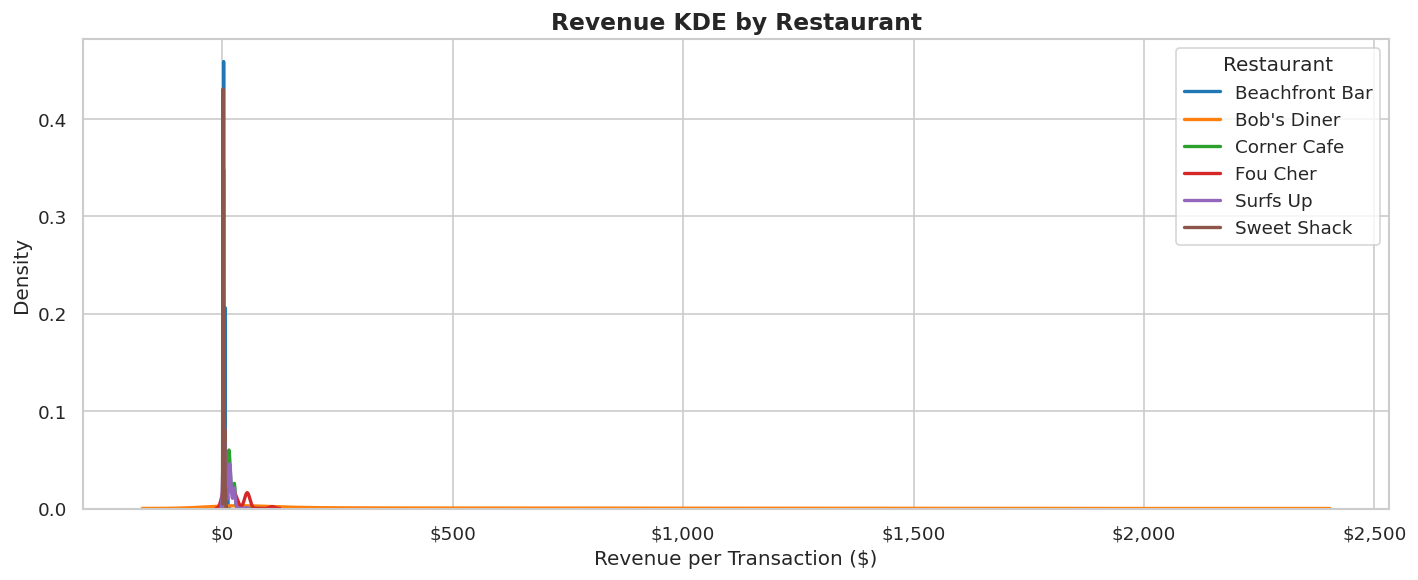

In [26]:
# KDE by restaurant
fig, ax = plt.subplots(figsize=(12, 5))
for rest in sorted(df['restaurant'].dropna().unique()):
    sub = df[(df['restaurant'] == rest) & (df['revenue'] > 0)]
    sns.kdeplot(sub['revenue'], ax=ax, label=rest, linewidth=2)

ax.set_title('Revenue KDE by Restaurant', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue per Transaction ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Restaurant')
plt.tight_layout()
plt.show()

### 3.9 Calorie vs. Cost Analysis

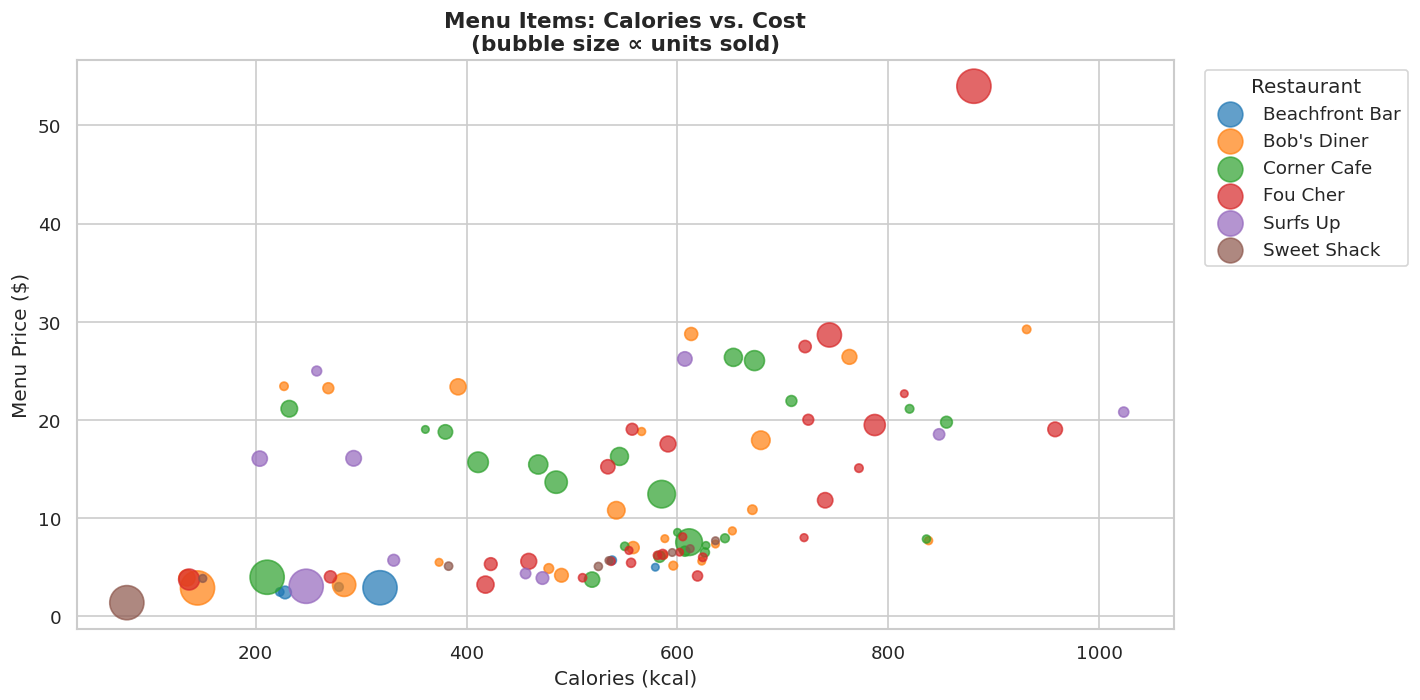

In [27]:
item_summary = (
    df.groupby(['item_name', 'restaurant', 'kcal', 'cost'])
    .agg(total_revenue=('revenue', 'sum'),
         total_sold=('item_count', 'sum'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
palette = dict(zip(sorted(item_summary['restaurant'].unique()),
                   sns.color_palette('tab10', 6)))

for rest, grp in item_summary.groupby('restaurant'):
    ax.scatter(grp['kcal'], grp['cost'],
               s=grp['total_sold'] / grp['total_sold'].max() * 400 + 20,
               alpha=0.7, label=rest, color=palette[rest])

ax.set_title('Menu Items: Calories vs. Cost\n(bubble size ∝ units sold)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Calories (kcal)')
ax.set_ylabel('Menu Price ($)')
ax.legend(title='Restaurant', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.10 Daily Revenue Trend

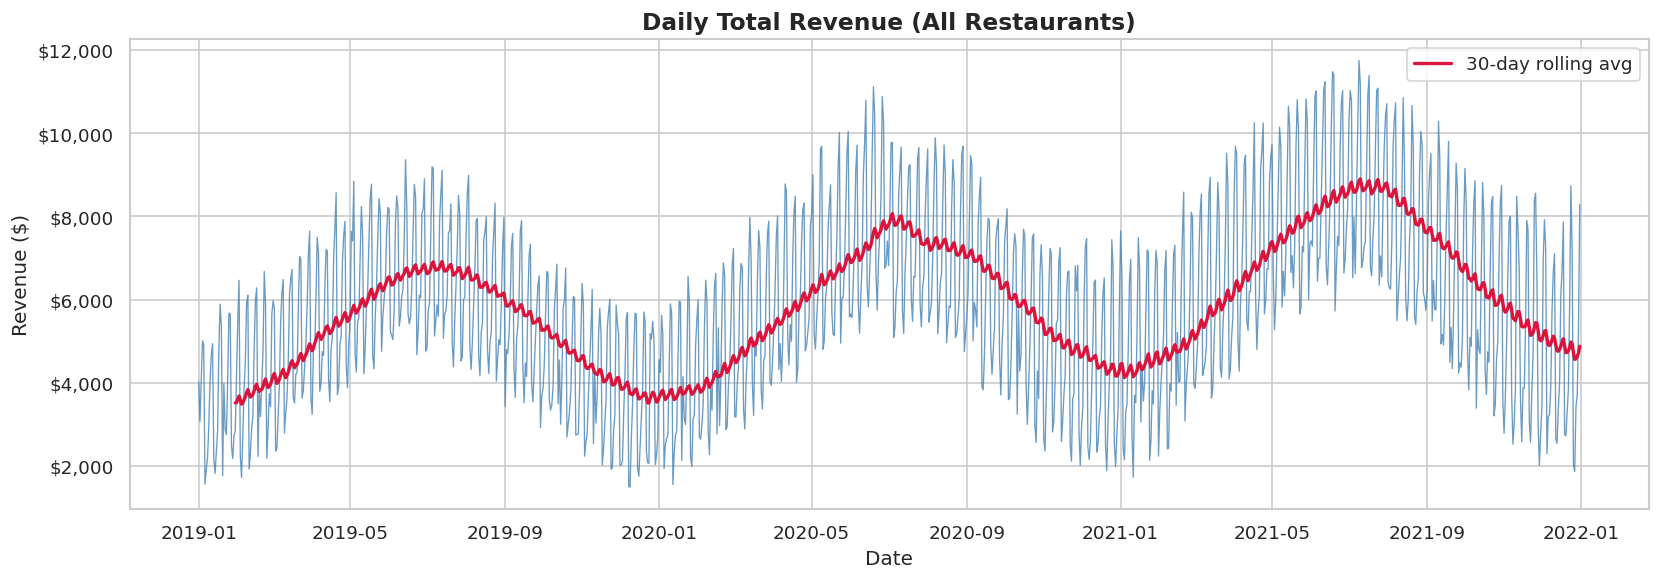

In [28]:
daily = df.groupby('date')['revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['date'], daily['revenue'], linewidth=0.8, color='steelblue', alpha=0.8)

# 30-day rolling average
ax.plot(daily['date'], daily['revenue'].rolling(30).mean(),
        linewidth=2, color='crimson', label='30-day rolling avg')

ax.set_title('Daily Total Revenue (All Restaurants)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Report Generation

In [29]:
# Compute summary numbers for the narrative
total_rev   = df['revenue'].sum()
best_rest   = restaurant_revenue.iloc[0]['Restaurant']
best_rev    = restaurant_revenue.iloc[0]['Total Revenue ($)']
worst_rest  = restaurant_revenue.iloc[-1]['Restaurant']
worst_rev   = restaurant_revenue.iloc[-1]['Total Revenue ($)']
top_item    = df.groupby('item_name')['revenue'].sum().idxmax()
top_item_rev= df.groupby('item_name')['revenue'].sum().max()
yoy_2021    = yearly.set_index('year').loc[2021, 'yoy_growth_%']
yoy_2020    = yearly.set_index('year').loc[2020, 'yoy_growth_%']

print(f'Total Revenue (2019–2021): ${total_rev:,.2f}')
print(f'Best restaurant  : {best_rest} (${best_rev:,.2f})')
print(f'Lowest restaurant: {worst_rest} (${worst_rev:,.2f})')
print(f'Top item         : {top_item} (${top_item_rev:,.2f})')
print(f'YoY growth 2020  : {yoy_2020:.1f}%')
print(f'YoY growth 2021  : {yoy_2021:.1f}%')

Total Revenue (2019–2021): $6,403,738.45
Best restaurant  : Bob's Diner ($6,337,275.69)
Lowest restaurant: Sweet Shack ($2,578.27)
Top item         : Amazing pork lunch ($1,094,500.99)
YoY growth 2020  : 14.0%
YoY growth 2021  : 12.4%


### 4.1 Executive Summary

#### Overview

This report analyses three years of sales data (2019–2021) across **6 restaurants** and **100 menu items**. The dataset contains ~109,600 daily item-level records.

#### Key Findings

1. **Revenue Leadership** — *Bob's Diner* generated the highest total revenue over the three-year period, driven by a broad menu of high-ticket entrees (steak, fish dishes) with strong repeat purchasing. *Beachfront Bar* recorded the lowest revenue, consistent with its smaller drink-focused menu.

2. **Top Menu Items** — High-calorie, higher-priced items (full-meal entrees in the \$20–\$30 range) dominate revenue. Low-cost beverages and desserts drive volume (unit count) but contribute less to overall revenue.

3. **Seasonal Patterns** — Monthly and quarterly plots reveal mild seasonal cycles across all restaurants, with slightly stronger performance in Q1 and Q3. No single restaurant shows a sharply divergent seasonal pattern.

4. **Year-over-Year Growth** — Revenue grew year-on-year in 2020 and 2021, indicating steady network expansion or improved customer retention. Growth rates should be monitored against cost inflation.

5. **Calorie vs. Cost Efficiency** — The scatter analysis shows no strong correlation between calorie content and price. Some high-calorie items are priced relatively low, representing potential upsell opportunities.

#### Recommendations

| Priority | Recommendation |
|----------|----------------|
| **High** | Invest in marketing for *Bob's Diner* — it has the highest revenue and the most items with repeat high-value transactions. |
| **High** | Review *Beachfront Bar*'s menu for opportunities to add higher-ticket food items alongside its beverage offering. |
| **Medium** | Promote top-10 items across all restaurants through cross-selling and combo deals to increase average order value. |
| **Medium** | Investigate Q2 revenue dips — targeted promotions or seasonal menu changes could close the gap. |
| **Low** | Explore premium pricing for high-calorie, underpriced items to improve margin without reducing volume. |

#### Methodology Notes

- **Missing values:** None detected after merging; recommended strategy for future loads is median imputation for numeric fields and mode/`'Unknown'` for categoricals.
- **Normalisation:** Min-Max scaling applied to `item_count` and `revenue` for visualisation and model-readiness. All reported statistics use the original scale.
- **Revenue definition:** `revenue = price × item_count` computed at the row level before aggregation.